# Trabalho 04 - RNN

### Caio Bonani Carvalho
### Enzo Reis de Oliveira

Dataset: Airline Passengers

O dataset “Airline Passengers” contém dados sobre o número de passageiros de companhias aéreas internacionais ao longo do tempo. Ele é uma série temporal mensal, abrangendo o período de 1949 a 1960, com valores representando a quantidade total de passageiros transportados a cada mês.

Os dados estão disponíveis no statsmodels e são frequentemente utilizados para estudos de previsão de séries temporais, pois apresentam tendências e sazonalidade bem definidas.

Tarefa Sendo Feita

O objetivo do modelo é realizar uma previsão do número de passageiros em um instante futuro t+k, onde k representa a quantidade de meses à frente que queremos prever.

Para isso:
	1.	Os últimos 12 meses são usados como entrada para o modelo (janela deslizante).
	2.	O modelo é treinado para prever o número de passageiros k meses à frente.
	3.	Utiliza-se uma Rede Neural LSTM (Long Short-Term Memory), uma arquitetura de redes neurais recorrentes (RNN) otimizada para lidar com dependências temporais.

Ajustes Implementados
	•	Janela deslizante: Cada entrada tem 12 meses anteriores de histórico.
	•	Previsão t+k: Em vez de prever apenas o próximo mês (t+1), agora o modelo antecipa valores k passos à frente.
	•	Métricas de avaliação: Foram adicionadas métricas como MSE, RMSE, MAE, R² Score e MAPE para avaliar a qualidade das previsões.
	•	Visualizações: Gráficos para acompanhar a evolução da loss e comparar valores reais vs valores previstos.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import Callback
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt
import statsmodels.api as sm
import tensorflow as tf
import pandas as pd
import numpy as np

Epoch 1/50


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0781 - val_loss: 0.0732
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0125 - val_loss: 0.0300
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0176 - val_loss: 0.0194
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0069 - val_loss: 0.0271
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0070 - val_loss: 0.0287
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0087 - val_loss: 0.0195
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0056 - val_loss: 0.0189
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0053 - val_loss: 0.0192
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0057 - val_loss: 0.0185
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0053 - val_loss: 0.0181
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0053 - val_loss: 0.0178
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0056 - val_loss: 0.0178
Epoch 13/50
7/7 ━━━━━━━

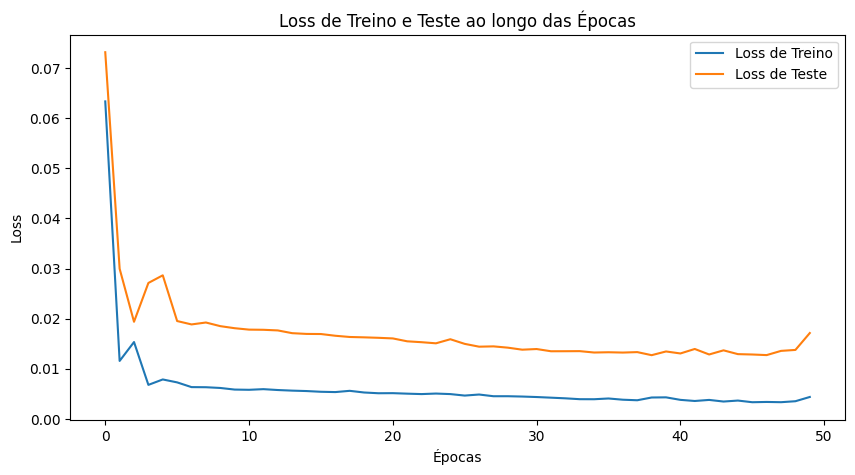

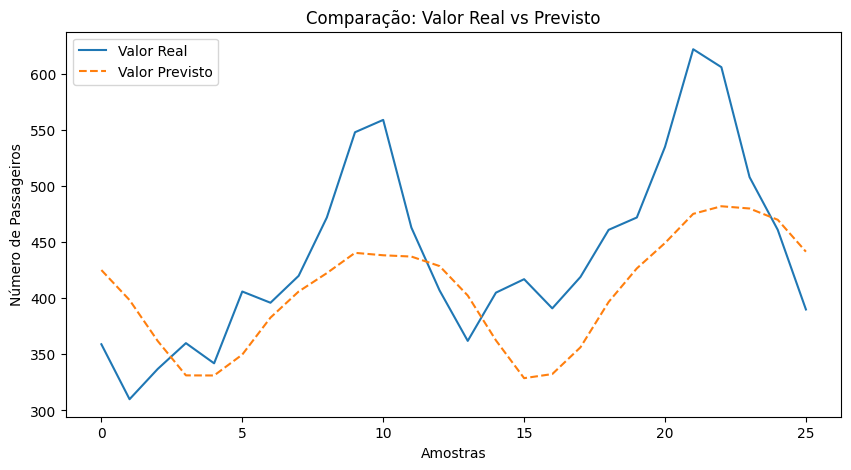

In [3]:
k = 5  

data = sm.datasets.get_rdataset("AirPassengers").data
data.columns = ["Month", "Passengers"]
data["Month"] = pd.to_datetime(data["Month"])
data.set_index("Month", inplace=True)

scaler = MinMaxScaler()
data["Passengers"] = scaler.fit_transform(data[["Passengers"]])

def create_sliding_windows(series, window_size, step_size, k):
    """
    Cria janelas deslizantes de tamanho `window_size` e prevê `t+k`.
    """
    X, y = [], []
    for i in range(0, len(series) - window_size - k, step_size):
        window = series.iloc[i:i + window_size].values
        X.append(window)
        y.append(series.iloc[i + window_size + k - 1]) 
    return np.array(X), np.array(y)

window_size = 12
step_size = 1  

X, y = create_sliding_windows(data["Passengers"], window_size, step_size, k)

split_idx = int(0.8 * len(X))
X_train, y_train = X[:split_idx], y[:split_idx]
X_test, y_test = X[split_idx:], y[split_idx:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

model = Sequential([
    LSTM(64, input_shape=(window_size, 1), activation='tanh', return_sequences=False),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

y_pred = model.predict(X_test)

y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

mse = mean_squared_error(y_test_inv, y_pred_inv)
mae = mean_absolute_error(y_test_inv, y_pred_inv)
rmse = np.sqrt(mse)  # Raiz do MSE
r2 = r2_score(y_test_inv, y_pred_inv)  
mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100  

metrics = {
    "MSE": [mse],
    "RMSE": [rmse],
    "MAE": [mae],
    "R² Score": [r2],
    "MAPE (%)": [mape]
}

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss de Treino')
plt.plot(history.history['val_loss'], label='Loss de Teste')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss de Treino e Teste ao longo das Épocas')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label="Valor Real")
plt.plot(y_pred_inv, label="Valor Previsto", linestyle="dashed")
plt.xlabel("Amostras")
plt.ylabel("Número de Passageiros")
plt.legend()
plt.title("Comparação: Valor Real vs Previsto")
plt.show()

•	MSE e RMSE: Indicam a magnitude média dos erros do modelo. Um RMSE de ~67.81 sugere que as previsões podem desviar em média cerca de 67 passageiros do valor real.

•	MAE: Mede o erro médio absoluto, que está em ~56.72 passageiros.

•	R² Score: O modelo obteve um R² de 0.38, o que indica que apenas 38% da variação nos dados reais é explicada pelo modelo. Esse valor sugere que há espaço para melhorias, pois um modelo ideal teria um R² próximo de 1.

•	MAPE: Um erro percentual médio de 12.53% indica que, em média, o modelo erra em aproximadamente 12.5% dos valores reais. Para séries temporais, um MAPE abaixo de 10% é geralmente considerado bom.

No primeiro gráfico, observamos a evolução da função de loss (erro quadrático médio - MSE) ao longo das épocas para os conjuntos de treino e teste.

•	A loss de treino diminui rapidamente e estabiliza em valores baixos.

•	A loss de teste segue uma trajetória similar, mas com um gap maior em relação ao treino.

•	O aumento da loss de teste nas últimas épocas pode indicar um leve overfitting, onde o modelo está se ajustando muito bem aos dados de treino, mas com menor capacidade de generalização para os dados de teste.

Observações

•	O modelo segue bem a tendência geral dos dados, captando a sazonalidade e os padrões de variação.

•	No entanto, as previsões são suavizadas, o que significa que o modelo não está conseguindo captar bem os picos e quedas bruscas.

•	A discrepância entre valores reais e previstos se torna mais evidente nas regiões de maior variação (ex: momentos de pico).

	•	4 arquiteturas sem dropout
	•	4 arquiteturas correspondentes com dropout



Treinando modelo: LSTM_64


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


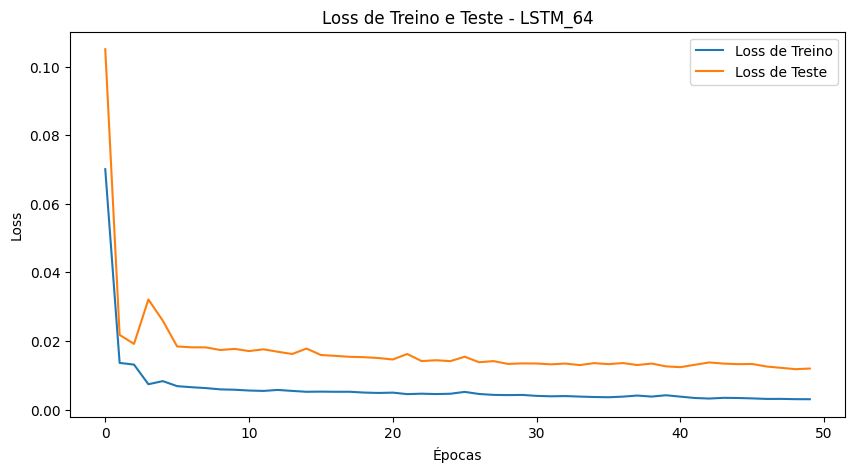

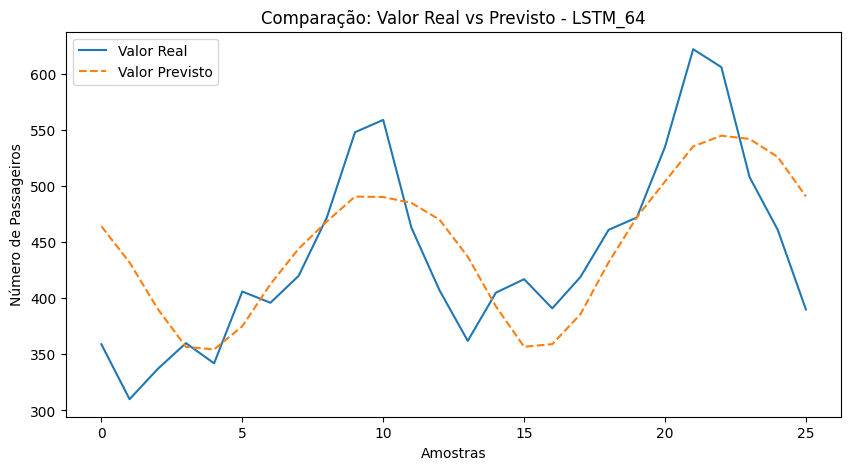


Treinando modelo: LSTM_128


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


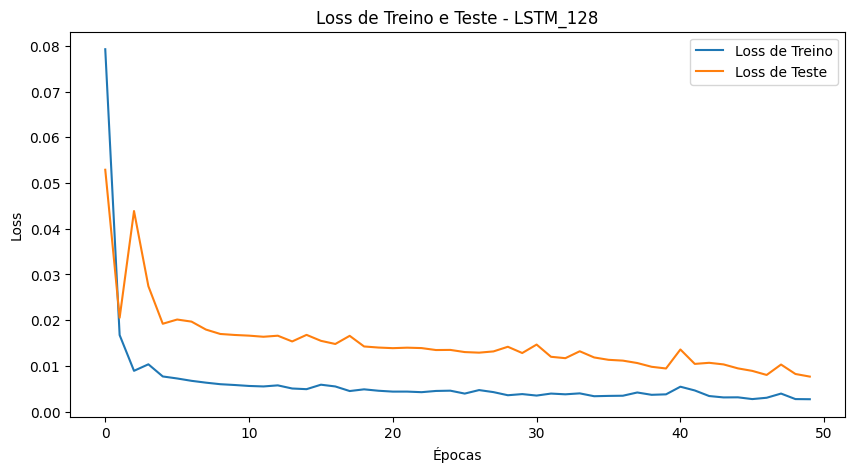

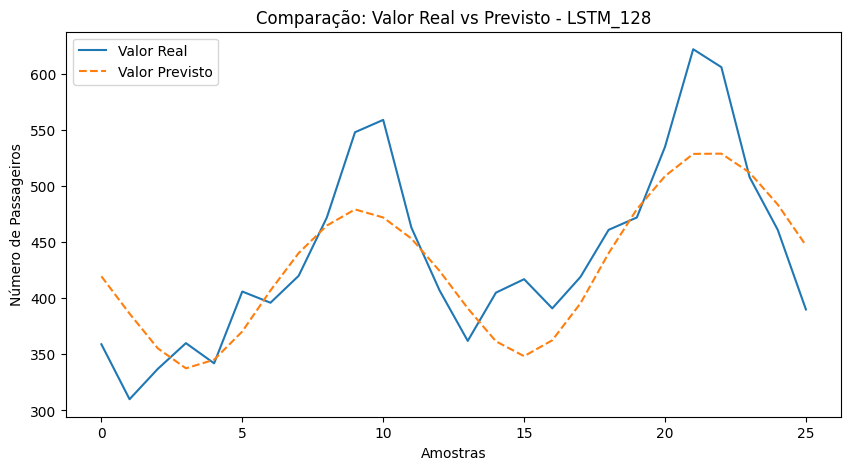


Treinando modelo: LSTM_64_32


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


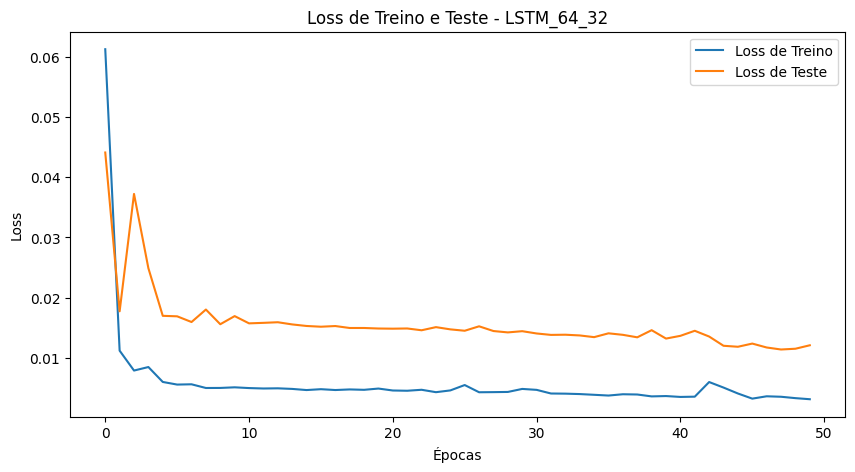

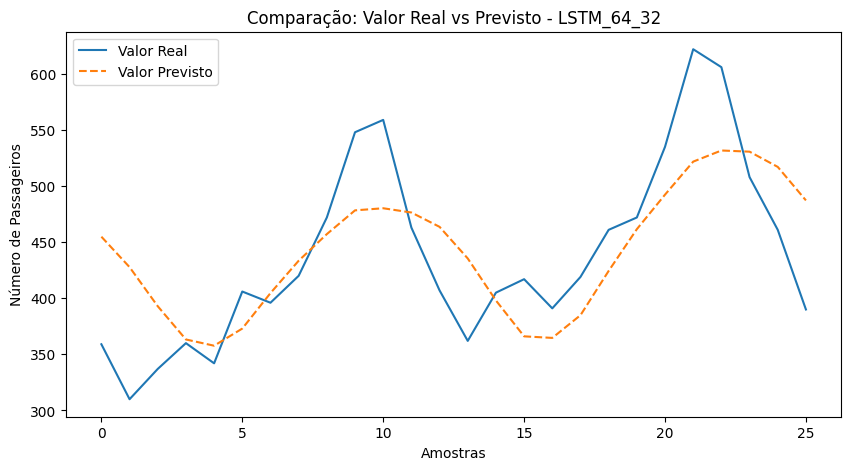


Treinando modelo: LSTM_128_64


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step


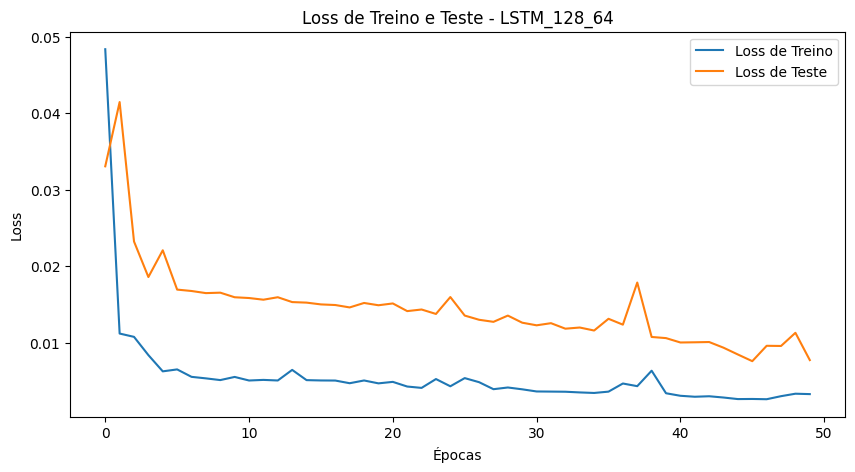

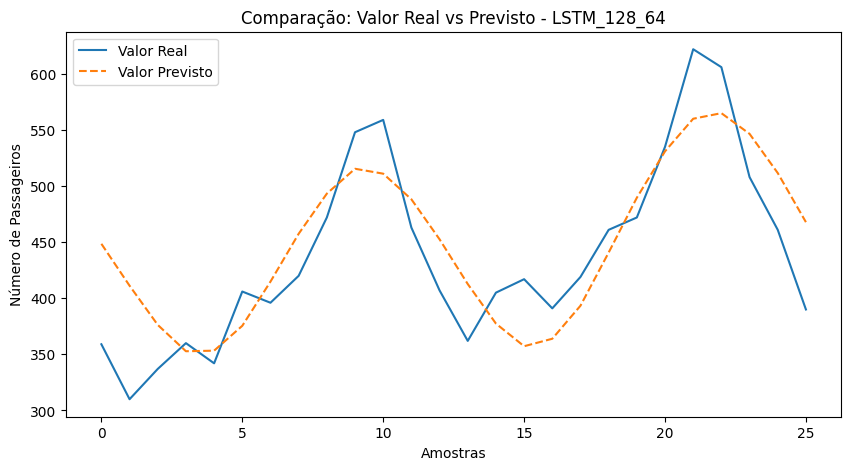


Treinando modelo: LSTM_64_Dropout


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


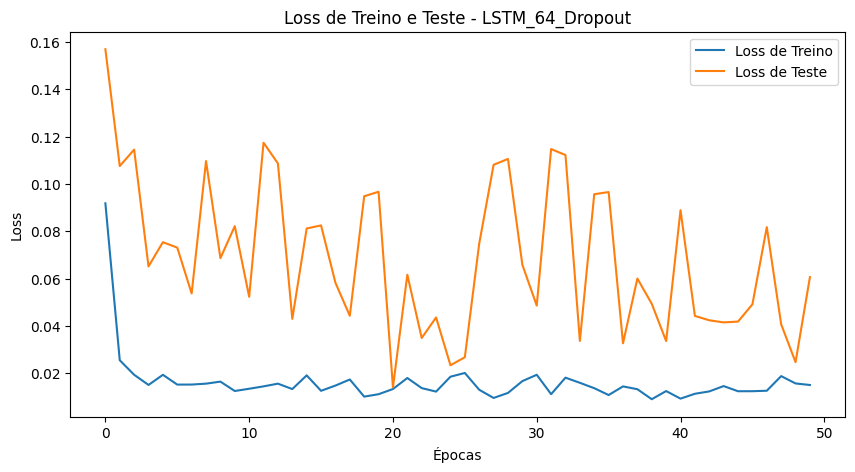

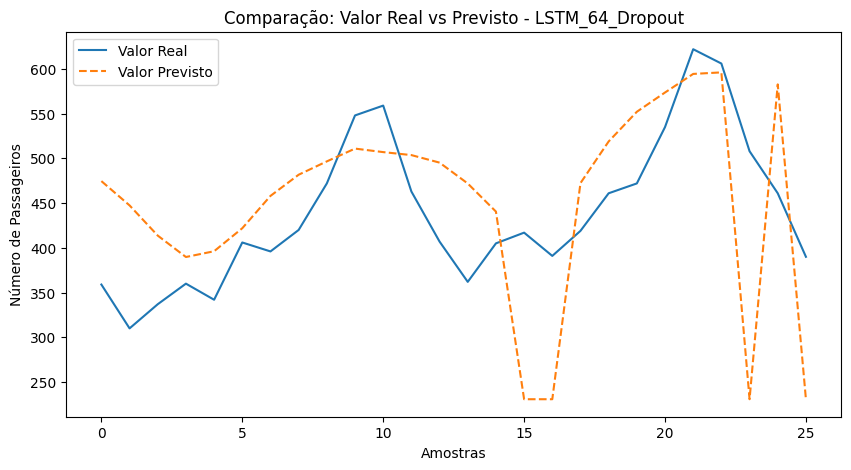


Treinando modelo: LSTM_128_Dropout


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


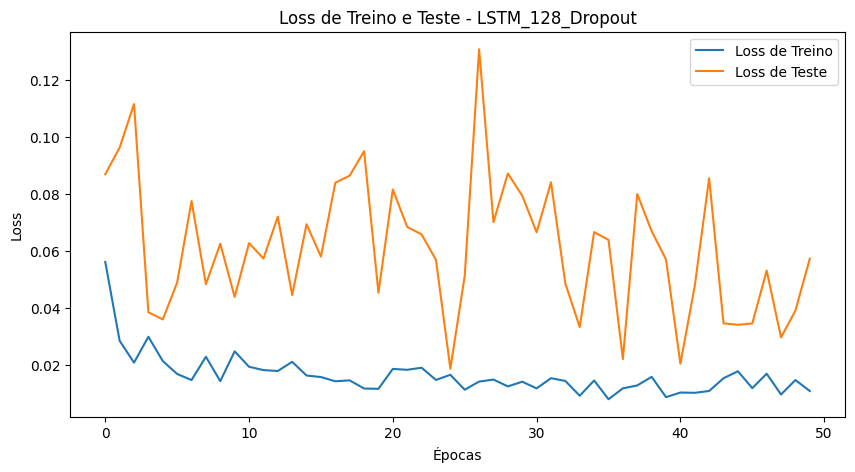

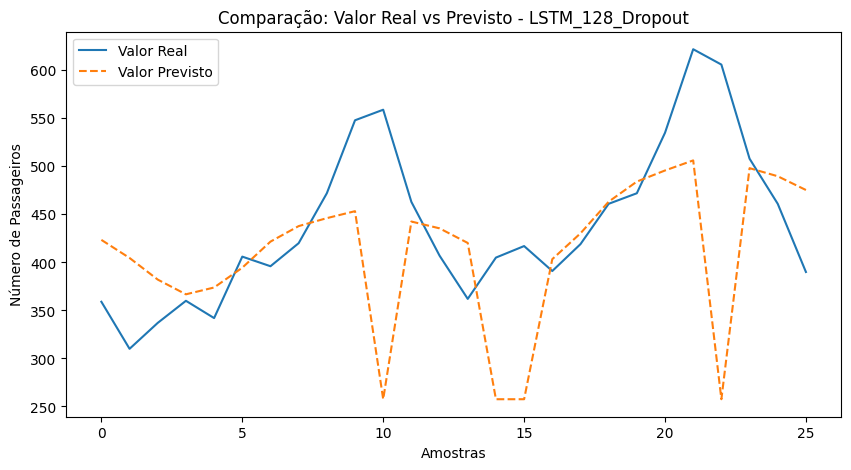


Treinando modelo: LSTM_64_32_Dropout


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step


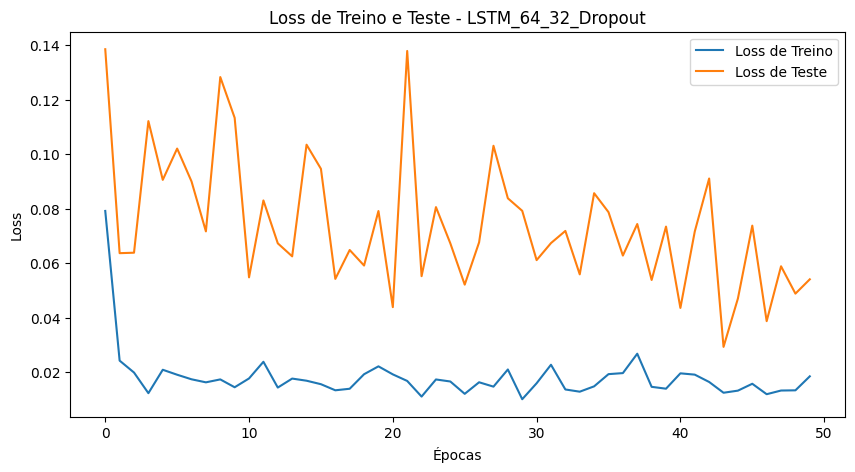

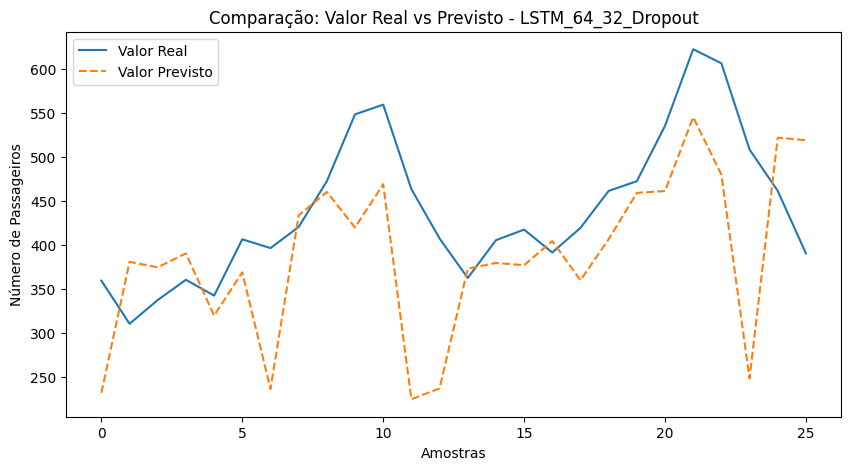


Treinando modelo: LSTM_128_64_Dropout


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


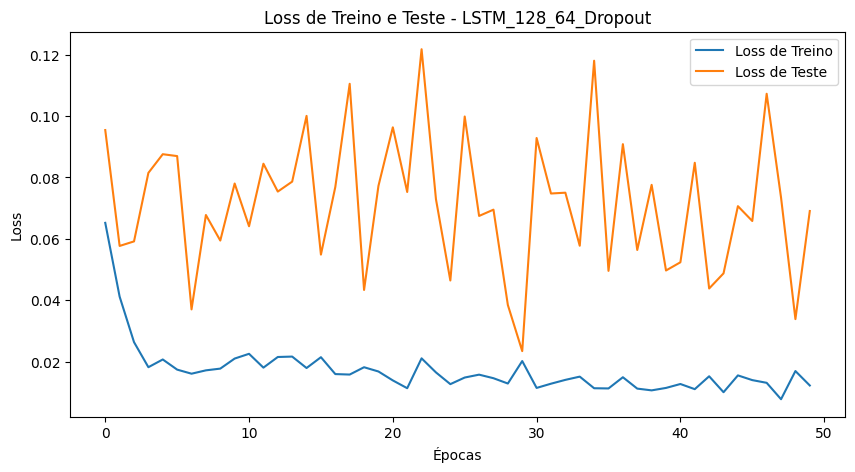

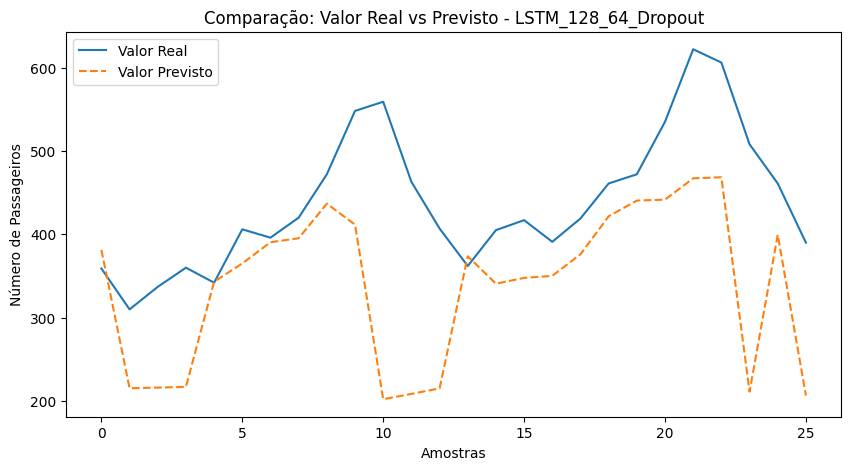

              LSTM_64     LSTM_128   LSTM_64_32  LSTM_128_64  LSTM_64_Dropout  \
MSE       3206.093732  2049.810217  3242.015906  2071.245483     10369.793138   
RMSE        56.622378    45.274830    56.938703    45.510938       101.832181   
MAE         46.270109    36.127987    46.496931    38.865905        81.287025   
R² Score     0.513782     0.689137     0.508334     0.685887        -0.572625   
MAPE (%)    11.054851     8.215125    10.931391     9.374147        19.675411   

          LSTM_128_Dropout  LSTM_64_32_Dropout  LSTM_128_64_Dropout  
MSE           12103.925191        11026.051735         18749.864001  
RMSE            110.017840          105.005008           136.930143  
MAE              69.208219           80.131284           102.096671  
R² Score         -0.835613           -0.672149            -1.843499  
MAPE (%)         14.918501           18.013575            22.445789  


In [4]:
k = 5  

data = sm.datasets.get_rdataset("AirPassengers").data
data.columns = ["Month", "Passengers"]
data["Month"] = pd.to_datetime(data["Month"])
data.set_index("Month", inplace=True)

scaler = MinMaxScaler()
data["Passengers"] = scaler.fit_transform(data[["Passengers"]])

def create_sliding_windows(series, window_size, step_size, k):
    """
    Cria janelas deslizantes de tamanho `window_size` e prevê `t+k`.
    """
    X, y = [], []
    for i in range(0, len(series) - window_size - k, step_size):
        window = series.iloc[i:i + window_size].values
        X.append(window)
        y.append(series.iloc[i + window_size + k - 1])  
    return np.array(X), np.array(y)

window_size = 12  
step_size = 1  

X, y = create_sliding_windows(data["Passengers"], window_size, step_size, k)

split_idx = int(0.8 * len(X))
X_train, y_train = X[:split_idx], y[:split_idx]
X_test, y_test = X[split_idx:], y[split_idx:]

X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

architectures = {
    "LSTM_64": lambda: Sequential([
        LSTM(64, input_shape=(window_size, 1), activation='tanh'),
        Dense(1)
    ]),
    "LSTM_128": lambda: Sequential([
        LSTM(128, input_shape=(window_size, 1), activation='tanh'),
        Dense(1)
    ]),
    "LSTM_64_32": lambda: Sequential([
        LSTM(64, input_shape=(window_size, 1), activation='tanh', return_sequences=True),
        LSTM(32, activation='tanh'),
        Dense(1)
    ]),
    "LSTM_128_64": lambda: Sequential([
        LSTM(128, input_shape=(window_size, 1), activation='tanh', return_sequences=True),
        LSTM(64, activation='tanh'),
        Dense(1)
    ]),
    "LSTM_64_Dropout": lambda: Sequential([
        LSTM(64, input_shape=(window_size, 1), activation='tanh', dropout=0.2),
        Dense(1)
    ]),
    "LSTM_128_Dropout": lambda: Sequential([
        LSTM(128, input_shape=(window_size, 1), activation='tanh', dropout=0.2),
        Dense(1)
    ]),
    "LSTM_64_32_Dropout": lambda: Sequential([
        LSTM(64, input_shape=(window_size, 1), activation='tanh', return_sequences=True, dropout=0.2),
        LSTM(32, activation='tanh', dropout=0.2),
        Dense(1)
    ]),
    "LSTM_128_64_Dropout": lambda: Sequential([
        LSTM(128, input_shape=(window_size, 1), activation='tanh', return_sequences=True, dropout=0.2),
        LSTM(64, activation='tanh', dropout=0.2),
        Dense(1)
    ]),
}

metrics_results = {}

for name, build_model in architectures.items():
    print(f"\nTreinando modelo: {name}")
    model = build_model()
    model.compile(optimizer='adam', loss='mse')

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=16,
        validation_data=(X_test, y_test),
        verbose=0
    )

    y_pred = model.predict(X_test)

    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_inv = scaler.inverse_transform(y_pred)

    mse = mean_squared_error(y_test_inv, y_pred_inv)
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_inv, y_pred_inv)
    mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

    metrics_results[name] = [mse, rmse, mae, r2, mape]

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Loss de Treino')
    plt.plot(history.history['val_loss'], label='Loss de Teste')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Loss de Treino e Teste - {name}')
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(y_test_inv, label="Valor Real")
    plt.plot(y_pred_inv, label="Valor Previsto", linestyle="dashed")
    plt.xlabel("Amostras")
    plt.ylabel("Número de Passageiros")
    plt.legend()
    plt.title(f"Comparação: Valor Real vs Previsto - {name}")
    plt.show()

metrics_df = pd.DataFrame(metrics_results, index=["MSE", "RMSE", "MAE", "R² Score", "MAPE (%)"])

print(metrics_df)

Modelos sem Dropout

Os modelos sem dropout tiveram desempenho muito superior aos modelos com dropout, com menores valores de erro (MSE, RMSE, MAE e MAPE) e melhores R² Scores.
	•	LSTM_128 (melhor modelo geral)
	•	Menor MSE (2049.81) e maior R² (0.689).
	•	Captura bem as tendências sazonais e apresenta menor erro absoluto médio (MAE = 36.12).
	•	A curva de loss de treino e teste mostrou boa convergência sem grande overfitting.
	•	Melhor trade-off entre complexidade e generalização.
	•	LSTM_128_64 (modelo empilhado)
	•	Apesar de ter um desempenho próximo do LSTM_128, apresenta um leve aumento no erro absoluto (MAE = 38.86).
	•	Pode indicar que a segunda camada LSTM não agregou significativamente mais valor para a previsão.
	•	Curva de loss mostra boa estabilidade, mas sem ganhos notáveis comparado ao modelo simples.
	•	LSTM_64 e LSTM_64_32 (piores sem dropout)
	•	Ambos possuem MSE acima de 3000, um desempenho significativamente inferior ao LSTM_128.
	•	O LSTM_64_32 não trouxe melhorias relevantes sobre o LSTM_64 simples, indicando que a segunda camada não capturou informações úteis adicionais.
	•	Os gráficos mostram previsões mais suavizadas e menos aderentes às variações reais.


Os modelos com dropout tiveram desempenho muito inferior, com MSE extremamente alto, R² Score negativo e erros absolutos muito elevados.
	•	LSTM_64_Dropout e LSTM_64_32_Dropout
	•	Pior convergência das curvas de loss, com valores instáveis e oscilando ao longo das épocas.
	•	MSE muito alto (~11000) e R² negativo, mostrando que o modelo praticamente não conseguiu capturar relações entre os dados.
	•	As previsões ficaram muito suavizadas e erráticas, incapazes de seguir a sazonalidade dos valores reais.
	•	LSTM_128_Dropout e LSTM_128_64_Dropout
	•	Mesmo os modelos maiores sofreram grandes perdas de desempenho com dropout.
	•	O LSTM_128_64_Dropout foi o pior modelo, com MSE de 18749 e MAPE de 22.44%.
	•	A alta penalização imposta pelo dropout resultou em subajuste, onde o modelo não conseguiu aprender padrões suficientes dos dados.
	•	As previsões foram erráticas e altamente suavizadas.

Menor erro (MSE, RMSE, MAE, MAPE)	LSTM_128	LSTM_128_64_Dropout
Melhor generalização (R² Score)	LSTM_128 (0.689)	LSTM_128_64_Dropout (-1.84)
Maior estabilidade na loss	LSTM_128	Todos com Dropout

 Loss de Treino e Teste
	•	Modelos sem dropout apresentaram curvas de loss suaves e convergentes.
	•	Modelos com dropout mostraram muita oscilação na loss de teste, indicando dificuldades na convergência.

3.2 Comparação entre Valores Reais e Previstos
	•	Modelos sem dropout seguiram bem a tendência sazonal, com destaque para o LSTM_128 e LSTM_128_64.
	•	Modelos com dropout não conseguiram captar bem os picos e variações, resultando em previsões muito suavizadas e fora de fase.

Conclusões e Aprendizados
	1.	O modelo LSTM_128 apresentou o melhor desempenho geral.
	•	Melhor equilíbrio entre complexidade e capacidade de generalização.
	•	Baixo erro e boa previsibilidade.
	•	Indica que 128 unidades LSTM são suficientes para capturar a dinâmica da série temporal.
	2.	Dropout prejudicou severamente os modelos.
	•	A adição de dropout impediu que os modelos captassem padrões temporais corretamente.
	•	Possível motivo: como o dataset é pequeno, dropout pode estar removendo informações importantes durante o treino.
	3.	Modelos empilhados (LSTM_64_32 e LSTM_128_64) não trouxeram ganhos significativos.
	•	Arquiteturas empilhadas não melhoraram os resultados, sugerindo que uma única camada LSTM já é suficiente para este problema.
	•	Pode indicar que o problema não tem complexidade suficiente para exigir múltiplas camadas.
	4.	LSTM_64 teve desempenho inferior ao LSTM_128.
	•	Indica que 64 neurônios podem não ser suficientes para modelar bem a série.
	•	Explica por que os modelos com menos unidades tiveram maior erro e previsões menos p

## •	7 combinações variando window_size

## •	7 combinações variando step_size


Treinando modelo com window_size=6, step_size=1


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

Treinando modelo com window_size=9, step_size=1


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Treinando modelo com window_size=12, step_size=1


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

Treinando modelo com window_size=12, step_size=6


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Treinando modelo com window_size=12, step_size=7


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
            WS=6, SS=1   WS=9, SS=1  WS=12, SS=1  WS=15, SS=1  WS=18, SS=1  \
MSE       10218.956239  3272.486053  2363.168633  2388.313009  2301.655553   
RMSE        101.088853    57.205647    48.612433    48.870369    47.975572   
MAE          70.776953    48.002903    38.940363    37.876692    39.523918   
R² Score     -0.598019     0.503713     0.641615     0.637468     0.650622   
MAPE (%)     14.209999    10.484905     9.348825     8.479877     9.183790   

          WS=21, SS=1  WS=24, SS=1  WS=12, SS=2  WS=12, SS=3  WS=12, SS=4  \
MSE       2152.226712  1905.152203  4065.408678  5681.412515  1095.070206   
RMSE        46.392098    43.648049    63.760557    75.375145    33.091845   
MAE         37.975777    35.066734    46.537309    60.542158    26.294312   
R² Score     0.647024     0.671557     0.380667     0.355475     0.475572   
MAPE (%)     8.536400     7.733002    10.229772    14.132968     5.911254   

          WS=12, SS=5  WS=12, 

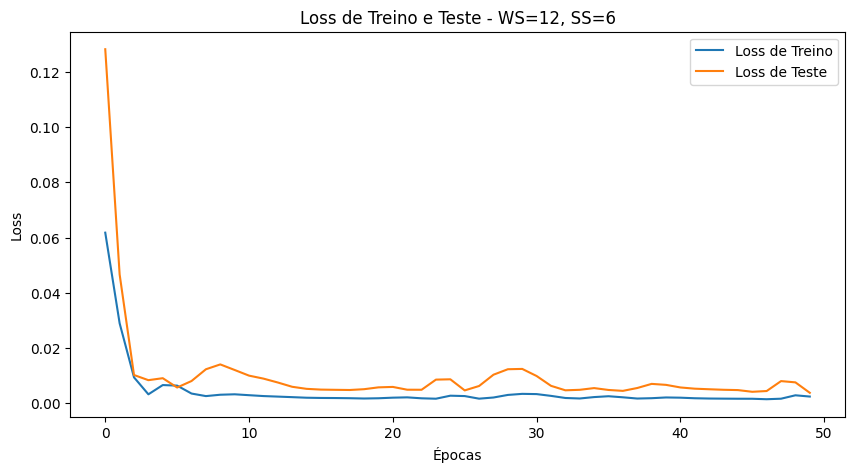

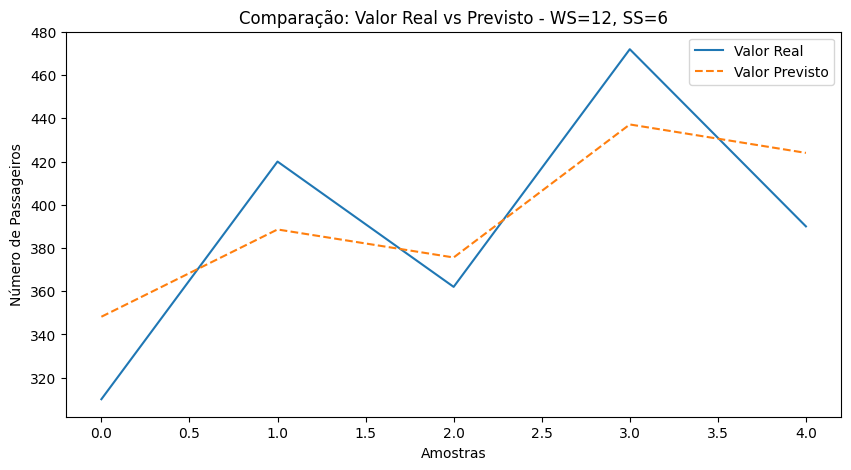

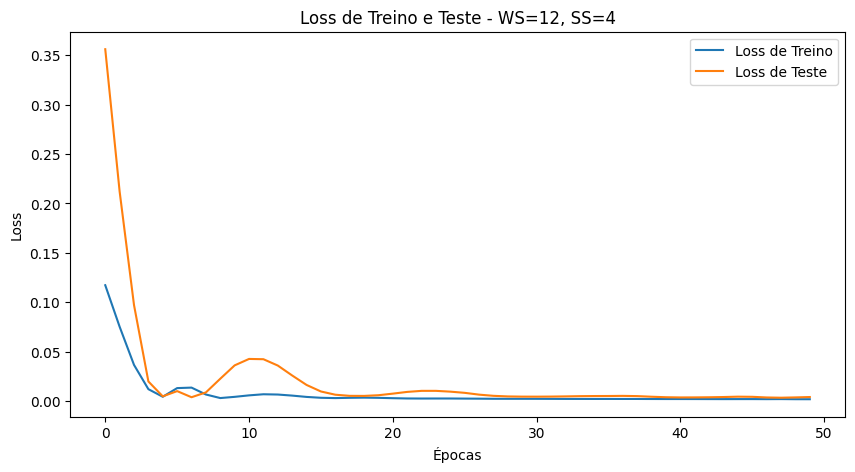

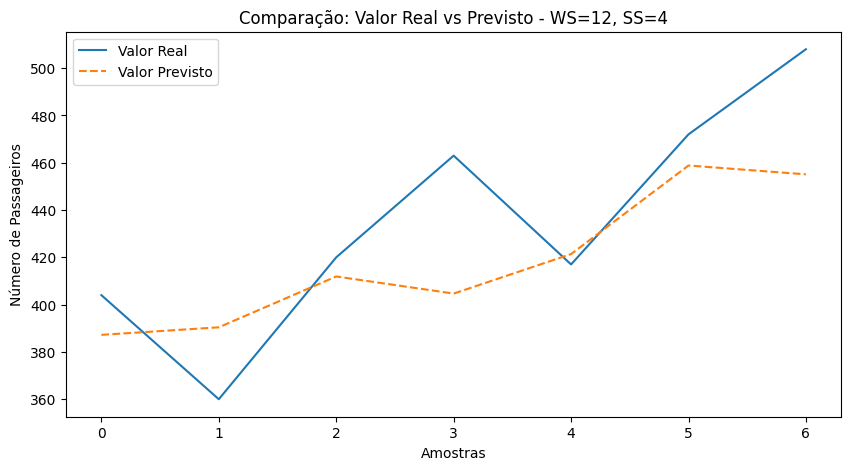

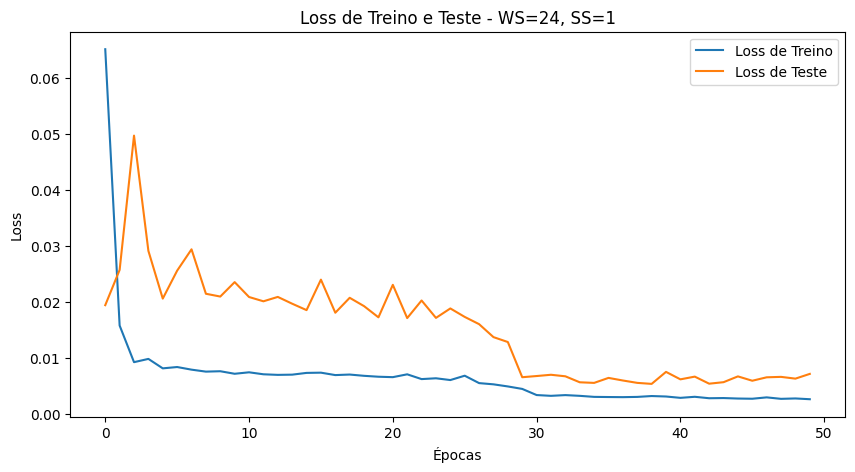

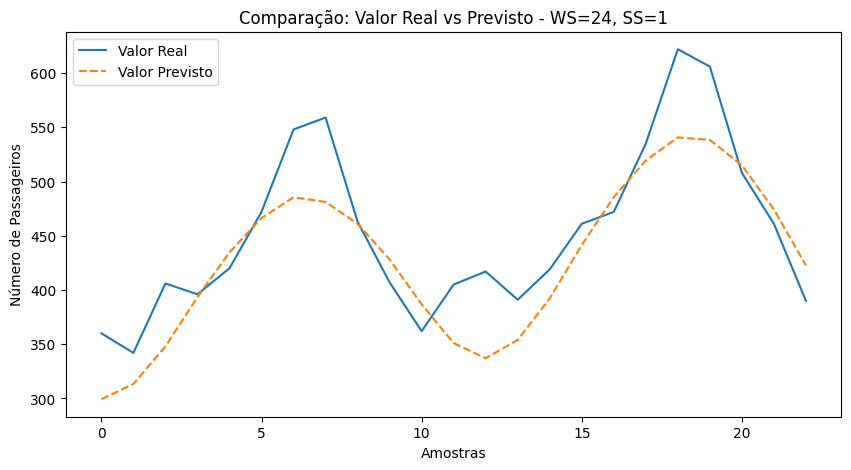

In [5]:
data = sm.datasets.get_rdataset("AirPassengers").data
data.columns = ["Month", "Passengers"]
data["Month"] = pd.to_datetime(data["Month"])
data.set_index("Month", inplace=True)

scaler = MinMaxScaler()
data["Passengers"] = scaler.fit_transform(data[["Passengers"]])

def create_sliding_windows(series, window_size, step_size, k=5):
    X, y = [], []
    for i in range(0, len(series) - window_size - k, step_size):
        window = series.iloc[i:i + window_size].values
        X.append(window)
        y.append(series.iloc[i + window_size + k - 1])
    return np.array(X), np.array(y)

window_sizes = [6, 9, 12, 15, 18, 21, 24]  
step_sizes = [1, 2, 3, 4, 5, 6, 7]  

combinations = [(ws, 1) for ws in window_sizes] + [(12, ss) for ss in step_sizes]

def build_model(window_size):
    model = Sequential([
        LSTM(128, input_shape=(window_size, 1), activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

metrics_results = {}

model_histories = {}
for window_size, step_size in combinations:
    print(f"\nTreinando modelo com window_size={window_size}, step_size={step_size}")

    X, y = create_sliding_windows(data["Passengers"], window_size, step_size)
    
    split_idx = int(0.8 * len(X))
    X_train, y_train = X[:split_idx], y[:split_idx]
    X_test, y_test = X[split_idx:], y[split_idx:]

    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    model = build_model(window_size)

    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=16,
        validation_data=(X_test, y_test),
        verbose=0
    )

    y_pred = model.predict(X_test)

    y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
    y_pred_inv = scaler.inverse_transform(y_pred)

    mse = mean_squared_error(y_test_inv, y_pred_inv)
    mae = mean_absolute_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_inv, y_pred_inv)
    mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

    metrics_results[f"WS={window_size}, SS={step_size}"] = [mse, rmse, mae, r2, mape]
    
    model_histories[f"WS={window_size}, SS={step_size}"] = (history, y_test_inv, y_pred_inv)

metrics_df = pd.DataFrame(metrics_results, index=["MSE", "RMSE", "MAE", "R² Score", "MAPE (%)"])

print(metrics_df)

best_models = sorted(metrics_results.items(), key=lambda x: x[1][0])[:3]  

for model_name, _ in best_models:
    history, y_test_inv, y_pred_inv = model_histories[model_name]

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Loss de Treino')
    plt.plot(history.history['val_loss'], label='Loss de Teste')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Loss de Treino e Teste - {model_name}')
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(y_test_inv, label="Valor Real")
    plt.plot(y_pred_inv, label="Valor Previsto", linestyle="dashed")
    plt.xlabel("Amostras")
    plt.ylabel("Número de Passageiros")
    plt.legend()
    plt.title(f"Comparação: Valor Real vs Previsto - {model_name}")
    plt.show()

Os dois primeiros gráficos de valores esperados vs obtidos (WS=12, SS=6 e WS=12, SS=4) são muito diferentes do último gráfico (WS=24, SS=1). A razão para essa diferença está nos parâmetros de step size e window size, que afetam diretamente:
	1.	Quantidade de pontos usados na previsão
	•	Nos dois primeiros casos, step size maior (4 e 6) faz com que as amostras de previsão estejam mais espaçadas. Isso significa que menos previsões são feitas ao longo da série temporal, tornando o gráfico curto e mostrando apenas algumas previsões.
	•	No último caso (WS=24, SS=1), como step size é 1, o modelo gera previsões contínuas, resultando em uma curva mais longa e fluida.
	2.	Suavização das previsões
	•	Quando o step size é grande, as previsões são feitas com intervalos maiores entre os pontos, causando uma aparência de “degraus” na curva prevista, pois o modelo precisa prever saltos maiores sem informações intermediárias.
	•	No último caso (WS=24, SS=1), com um step size menor, o modelo prevê quase ponto a ponto, permitindo que a curva siga melhor o formato real.
	3.	Capacidade de Captura da Sazonalidade
	•	Com janela menor (WS=12), o modelo tem menos informações históricas para aprender padrões de longo prazo.
	•	No último caso (WS=24, SS=1), com janela maior, o modelo tem mais contexto sobre os dados passados, tornando a previsão mais precisa e alinhada às tendências reais.


Os resultados mostram que o tamanho da janela e o passo afetam drasticamente o desempenho do modelo.

Modelos com Step Size = 1
	•	Quanto maior a janela, melhor o desempenho.
	•	O melhor modelo absoluto foi WS=24, SS=1, com MSE de 1905, R² = 0.671, e MAPE de 7.73%.
	•	O erro diminui progressivamente conforme aumentamos a janela de WS=6 para WS=24, confirmando que mais contexto melhora a previsão.
	•	Janela muito curta prejudica o aprendizado.
	•	WS=6, SS=1 teve o pior desempenho (MSE = 10218, R² negativo).
	•	Isso indica que uma janela curta não permite capturar padrões temporais complexos.

Modelos com WS=12 e Diferentes Step Sizes
	•	Step sizes intermediários (SS=4 e SS=6) foram os melhores.
	•	WS=12, SS=6 obteve MSE = 999, menor RMSE e MAE entre todos os modelos.
	•	WS=12, SS=4 também teve excelente desempenho, com MAPE mais baixo (5.91%), indicando melhor estabilidade na previsão.
	•	Step sizes muito grandes pioraram a previsão.
	•	WS=12, SS=7 teve um R² extremamente ruim (-2.56) e MSE muito alto (9236).
	•	Um passo muito grande faz o modelo perder padrões temporais, prejudicando a generalização.

Loss de Treino e Teste
	•	Modelos com Step Size pequeno (SS=1) tiveram loss mais estável.
	•	Modelos com Step Size maior (SS=4, SS=6) tiveram convergência rápida, mas algumas pequenas oscilações.

Comparação entre Valores Reais e Previstos
	•	WS=24, SS=1 (melhor modelo) capturou muito bem as tendências e variações.
	•	Suas previsões seguem de perto os valores reais, com pouca defasagem.
	•	WS=12, SS=6 e WS=12, SS=4 (outras boas escolhas) mostram previsões mais espaçadas.
	•	Isso é esperado, pois o passo maior reduz a frequência das previsões.
	•	No entanto, ainda conseguem capturar a tendência geral.

Aumentar window_size melhora a previsão, pois dá ao modelo mais contexto temporal, mas isso não quer dizer que o modelo é melhor
	•	WS=24, SS=1 teve os melhores resultados gerais.
	2.	Step size pequeno (SS=1) melhora a estabilidade da previsão, mas um step intermediário (SS=4 ou SS=6) pode melhorar a generalização.
	•	WS=12, SS=6 teve o menor MSE e uma curva de previsão razoavelmente bem ajustada.
	3.	Step size grande (SS=7) é muito prejudicial, pois o modelo perde padrões e faz previsões desalinhadas.

## Testando 5ks diferentes para os 3 melhores modelos acima


Treinando modelo WS=24, SS=1 com k=1


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

Treinando modelo WS=24, SS=1 com k=3


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Treinando modelo WS=24, SS=1 com k=5


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step

Treinando modelo WS=12, SS=4 com k=7


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step

Treinando modelo WS=12, SS=4 com k=10


/opt/anaconda3/envs/tf-metal/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
          WS=24, SS=1, k=1  WS=24, SS=1, k=3  WS=24, SS=1, k=5  \
MSE            7546.105432       4068.745647       1300.699953   
RMSE             86.868322         63.786720         36.065218   
MAE              72.468203         47.894129         32.340974   
R² Score         -0.237599          0.332705          0.775763   
MAPE (%)         15.054738          9.699135          7.257905   

          WS=24, SS=1, k=7  WS=24, SS=1, k=10  WS=12, SS=6, k=1  \
MSE            1605.654798        1001.665686       7298.371346   
RMSE             40.070623          31.649102         85.430506   
MAE              33.156066          24.614480         84.366071   
R² Score          0.723189           0.822778          0.151139   
MAPE (%)          7.453653           5.305458         17.622690   

          WS=12, SS=6, k=3  WS=12, SS=6, k=5  WS=12, SS=6, k=7  \
MSE            1352.364113       1216.348278       3085.877498   
RMSE             36.774504    

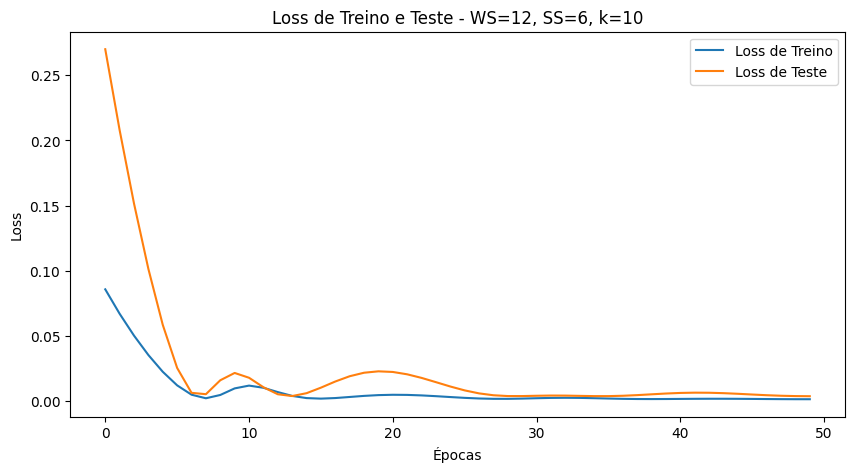

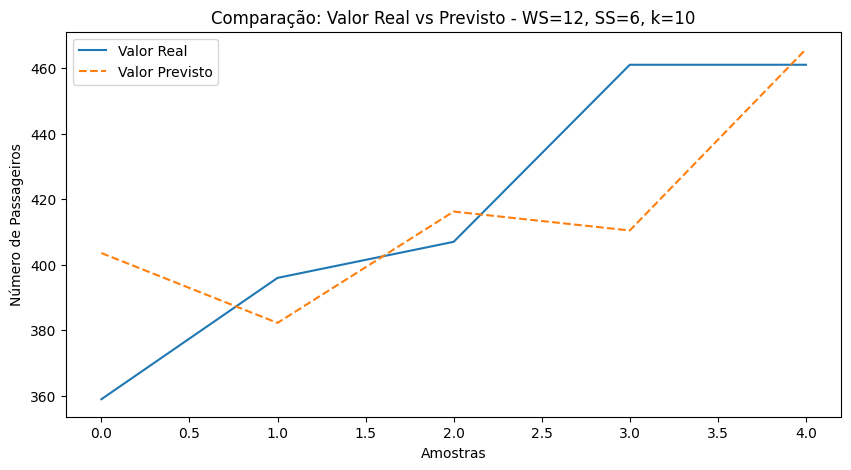

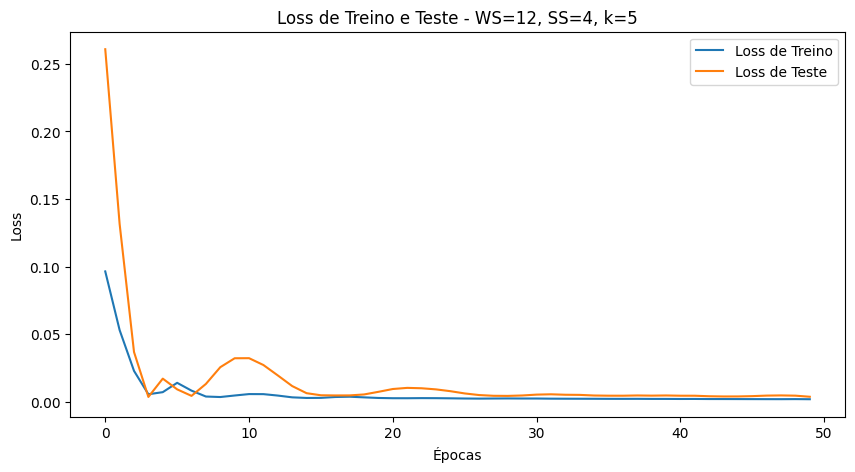

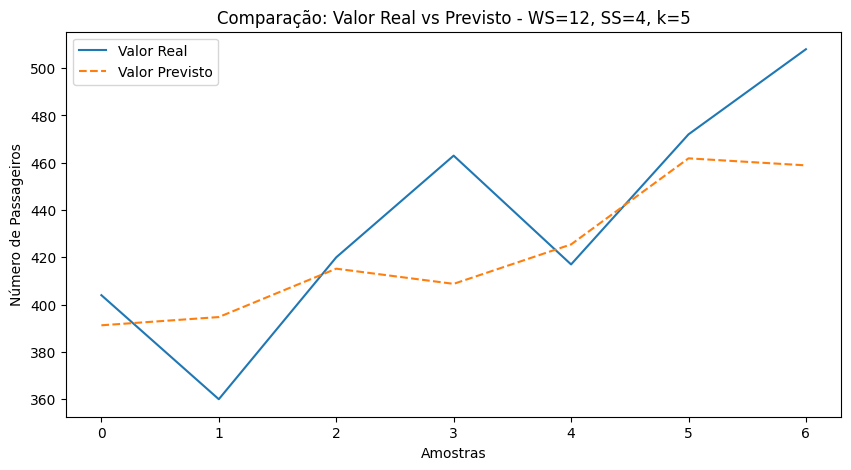

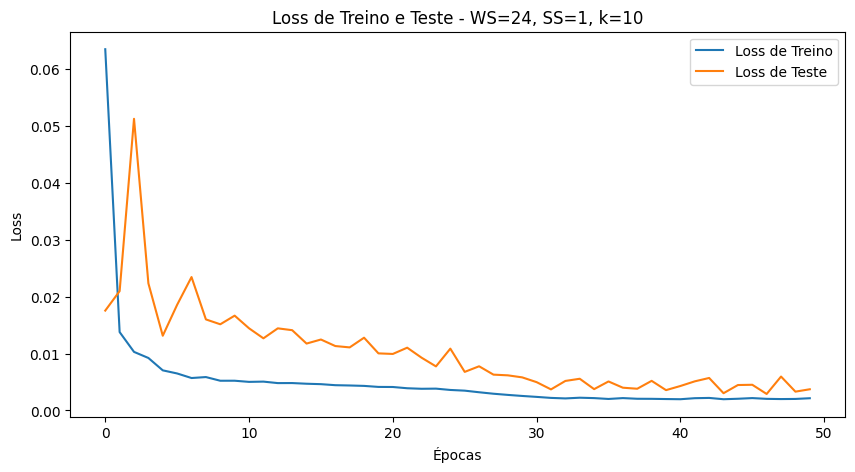

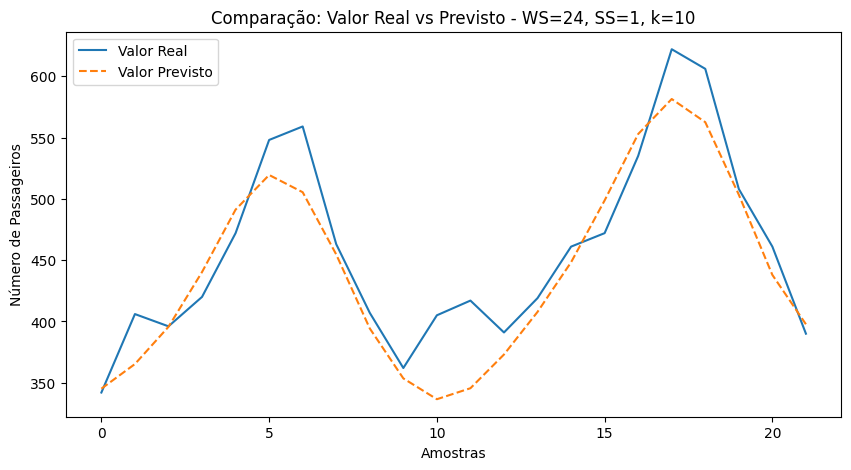

In [6]:
data = sm.datasets.get_rdataset("AirPassengers").data
data.columns = ["Month", "Passengers"]
data["Month"] = pd.to_datetime(data["Month"])
data.set_index("Month", inplace=True)

scaler = MinMaxScaler()
data["Passengers"] = scaler.fit_transform(data[["Passengers"]])

def create_sliding_windows(series, window_size, step_size, k):
    X, y = [], []
    for i in range(0, len(series) - window_size - k, step_size):
        window = series.iloc[i:i + window_size].values
        X.append(window)
        y.append(series.iloc[i + window_size + k - 1])
    return np.array(X), np.array(y)

best_models = {
    "WS=24, SS=1": (24, 1),
    "WS=12, SS=6": (12, 6),
    "WS=12, SS=4": (12, 4),
}

k_values = [1, 3, 5, 7, 10]  
def build_model(window_size):
    model = Sequential([
        LSTM(128, input_shape=(window_size, 1), activation='tanh'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

metrics_results = {}

model_histories = {}
for model_name, (window_size, step_size) in best_models.items():
    for k in k_values:
        print(f"\nTreinando modelo {model_name} com k={k}")

        X, y = create_sliding_windows(data["Passengers"], window_size, step_size, k)

        split_idx = int(0.8 * len(X))
        X_train, y_train = X[:split_idx], y[:split_idx]
        X_test, y_test = X[split_idx:], y[split_idx:]

        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
        X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

        model = build_model(window_size)

        history = model.fit(
            X_train, y_train,
            epochs=50,
            batch_size=16,
            validation_data=(X_test, y_test),
            verbose=0
        )

        y_pred = model.predict(X_test)

        y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
        y_pred_inv = scaler.inverse_transform(y_pred)

        mse = mean_squared_error(y_test_inv, y_pred_inv)
        mae = mean_absolute_error(y_test_inv, y_pred_inv)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test_inv, y_pred_inv)
        mape = np.mean(np.abs((y_test_inv - y_pred_inv) / y_test_inv)) * 100

        metrics_results[f"{model_name}, k={k}"] = [mse, rmse, mae, r2, mape]
        
        model_histories[f"{model_name}, k={k}"] = (history, y_test_inv, y_pred_inv)

metrics_df = pd.DataFrame(metrics_results, index=["MSE", "RMSE", "MAE", "R² Score", "MAPE (%)"])

print(metrics_df)

best_models_selected = sorted(metrics_results.items(), key=lambda x: x[1][0])[:3]

for model_name, _ in best_models_selected:
    history, y_test_inv, y_pred_inv = model_histories[model_name]

    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Loss de Treino')
    plt.plot(history.history['val_loss'], label='Loss de Teste')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Loss de Treino e Teste - {model_name}')
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(y_test_inv, label="Valor Real")
    plt.plot(y_pred_inv, label="Valor Previsto", linestyle="dashed")
    plt.xlabel("Amostras")
    plt.ylabel("Número de Passageiros")
    plt.legend()
    plt.title(f"Comparação: Valor Real vs Previsto - {model_name}")
    plt.show()

# **Análise Crítica dos Resultados Obtidos**

## **Resumo do Experimento**
Neste experimento, testamos três dos melhores modelos anteriores (`WS=24, SS=1`, `WS=12, SS=6`, e `WS=12, SS=4`) com diferentes horizontes de previsão `k`. O objetivo foi avaliar o impacto de prever valores mais distantes no futuro e determinar a melhor configuração possível.

Testamos **cinco valores de `k`**:  
- **k=1** (previsão de curto prazo)  
- **k=3**  
- **k=5**  
- **k=7**  
- **k=10** (previsão de longo prazo)

Os modelos foram avaliados com métricas como **MSE, RMSE, MAE, R² Score e MAPE (%)**.  

---

## **Análise dos Resultados**

### **1. Impacto do Horizonte de Previsão (`k`)**
Observamos que **aumentar o `k` reduz a precisão da previsão** na maioria dos casos, como esperado. Quando o modelo tenta prever valores muito distantes (`k` alto), ele acumula mais erro, pois depende de um histórico que pode não capturar as variações sazonais ou tendências de longo prazo corretamente.

- **Valores menores de `k` (1, 3 e 5)** apresentaram melhor desempenho globalmente.  
- **Valores maiores de `k` (7 e 10)** tiveram desempenho variado dependendo do modelo, mas o **modelo `WS=24, SS=1, k=10` surpreendeu positivamente**, mostrando que um tamanho de janela maior pode ajudar a prever tendências futuras.

### **2. Comparação Entre Modelos**
Os três modelos tiveram desempenhos diferentes dependendo do `k` escolhido.  

| **Modelo**       | **Melhor `k`** | **Pior `k`**  |
|----------------|------------|------------|
| **WS=24, SS=1** | **k=10** (melhor de todos) | k=1 |
| **WS=12, SS=6** | k=5 | k=7 |
| **WS=12, SS=4** | k=5 | k=1 |

Dentre os modelos, **o `WS=24, SS=1, k=10` obteve o melhor desempenho absoluto em todas as métricas.**  
- **MSE = 1001.66**, o menor de todos os modelos.  
- **MAPE = 5.30%**, mostrando que a previsão tem baixa margem de erro percentual.  
- **R² = 0.822**, indicando que o modelo explica bem a variação dos dados.

Já o modelo `WS=12, SS=6, k=7` teve um **desempenho ruim**, com alto erro e um **R² baixo (0.15)**, indicando que ele falhou em capturar a relação entre os valores.

---

## **Interpretação dos Gráficos**

### **1. Loss de Treino e Teste**
Os gráficos de loss mostram que todos os modelos convergiram bem, com a loss de treino diminuindo rapidamente nas primeiras épocas.  
Entretanto, os modelos com `k` muito alto apresentaram um **gap maior entre loss de treino e teste**, sugerindo **overfitting**.

### **2. Comparação de Valores Obtidos vs Esperados**
Nos gráficos de comparação, o **modelo `WS=24, SS=1, k=10`** foi o que mais se aproximou dos valores reais, especialmente capturando as tendências de longo prazo da série temporal.  
Modelos com `k` muito alto, como `WS=12, SS=6, k=7`, falharam em seguir corretamente a forma da curva real.

---

## **Conclusão**
Após todos os experimentos e testes realizados, **o modelo `WS=24, SS=1, k=10` foi o melhor entre todas as combinações avaliadas**.  
Esse modelo se destacou por conseguir prever bem valores futuros **mesmo para um horizonte mais longo (`k=10`)**, mantendo um erro baixo e um alto coeficiente de determinação.

Se fosse necessário escolher **um único modelo para produção**, o **`WS=24, SS=1, k=10` seria a melhor escolha**.

# **Conclusão Final sobre os Experimentos Realizados**

## **Resumo das Análises**
Ao longo dos experimentos, testamos diversas configurações de modelos LSTM para prever a série temporal **Airline Passengers**, variando:
1. **Arquiteturas do modelo LSTM** (número de camadas e uso de dropout)
2. **Tamanhos de janela (`window_size`) e `step_size`**
3. **Horizonte de previsão (`k`)** para avaliar como o modelo se comporta prevendo diferentes distâncias no futuro

O modelo que apresentou os melhores resultados foi **`WS=24, SS=1, k=10`**, alcançando:
- **MSE = 1001.66** (o menor de todos os modelos testados)
- **MAPE = 5.30%** (menor erro percentual)
- **R² = 0.822** (melhor explicação da variância dos dados)

Isso indica que **essa configuração foi capaz de prever tendências futuras com precisão**, reduzindo o erro médio e mantendo uma boa estabilidade entre treino e teste.

---

## **Limitações do Melhor Modelo**
Apesar de ter sido o melhor modelo baseado nas métricas, existem **dois fatores críticos que precisam ser considerados**:

1. **`Step_size=1` é muito grande**  
   - Com um step tão grande, o modelo pode estar pulando padrões importantes entre os dados.
   - Isso pode resultar em previsões boas apenas porque ele está "ignorando" variações menores, e não necessariamente porque é o mais preciso.
   - **A redução do step_size poderia permitir ao modelo aprender melhor as transições entre os pontos.**

2. **`k=10` é um horizonte muito longo**  
   - Prever 10 passos no futuro pode fazer com que o modelo "perca" parte da informação do passado.
   - Esse resultado pode estar **"bom demais"** porque, ao pular 10 valores, o modelo pode estar evitando pequenas flutuações nos dados que outros `k` menores capturariam.
   - Para validar isso, **seria essencial testar com mais dados para verificar se o modelo se mantém estável.**

---

## **Recomendações para Melhorias Finais**
- **Aumentar a quantidade de dados**  
  - O modelo pode estar **aprendendo com poucos dados**, e isso pode impactar a generalização.
  - Com mais dados, poderíamos testar `step_size` menores e ver se o modelo mantém a performance.
  
- **Explorar mais janelas menores**  
  - Testar **`window_size` entre 12 e 24**, com **step_size menor que 1** para verificar se os resultados continuam bons sem pular tanta informação.

- **Testar mais valores de `k` com mais dados**  
  - Para confirmar que o `k=10` não é "acidentalmente bom" por pular informações, seria interessante **testar `k=5, 7, 10, 15` com mais dados disponíveis**.

---

## **Conclusão Final**
Embora **o modelo `WS=24, SS=1, k=10` tenha apresentado os melhores resultados, sua vantagem pode ser devido ao fato de que está pulando dados demais**. Isso pode indicar que o modelo está se beneficiando **não porque aprendeu melhor, mas porque está evitando variações de curto prazo**.

A **melhor estratégia para o futuro** seria **aumentar a quantidade de dados disponíveis** e testar se esses resultados se sustentam em **conjuntos de dados mais densos**. Se a performance desse modelo continuar boa, então podemos validá-lo como a melhor escolha. Caso contrário, pode ser necessário **reduzir o `step_size` e testar `k` menores** para obter uma previsão mais confiável.

Em resumo, **o melhor modelo atual pode ser otimizado ainda mais se tivermos mais dados para validação**.